<a href="https://colab.research.google.com/github/ife-dolapo/Exploratory-Data-Analysis-with-Pandas/blob/main/Assignment_5_Exploratory_Data_Analysis_with_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Clone the repo
!git clone https://github.com/ife-dolapo/Exploratory-Data-Analysis-with-Pandas.git

Cloning into 'Exploratory-Data-Analysis-with-Pandas'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Task 1
# Load the dataset
titanic_df = pd.read_csv('Titanic-Dataset.csv')
print("The first 5 rows of the dataset:")
print(titanic_df.head())

The first 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37

In [7]:
# Task 2: Inspect the data
print("The first 5 rows of the dataset:")
print(titanic_df.head())

print("\nThe last 5 rows of the dataset:")
print(titanic_df.tail())

print("\nThe datatypes of the dataset:")
print(titanic_df.dtypes)

print("\nThe summary statistics of the dataset:")
print(titanic_df.describe())


The first 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37

## Dataset Overview: Titanic Passenger Data

This dataset contains information on 891 passengers aboard the Titanic, capturing demographic, ticketing, and survival details. Below are key insights drawn from the initial exploration:

### Structure & Composition
- **Total entries**: 891 passengers
- **Data types**:
  - Numerical: `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`
  - Categorical: `Sex`, `Embarked`, `Cabin`, `Ticket`, `Name`

### Survival Insights
- **Survival rate**: ~38.4% of passengers survived
- **Class distribution**:
  - Majority were in **3rd class** (mean Pclass ≈ 2.31)
  - Survivors were more likely to be in **1st class**, as seen in the first and last few rows

### Demographics
- **Age**:
  - Mean age: ~29.7 years
  - Age range: 0.42 to 80 years
  - Missing values: ~20% of entries lack age data
- **Gender**:
  - Gender appears correlated with survival (e.g., many female passengers survived)

### Family & Fare
- **SibSp (siblings/spouses aboard)**:
  - Most passengers traveled alone (median = 0)
- **Parch (parents/children aboard)**:
  - Similar trend with low counts (median = 0)
- **Fare**:
  - Highly skewed distribution (mean = 32.2, max = 512.3)
  - Indicates a wide range of ticket prices and socioeconomic diversity

### Embarkation & Cabin Info
- **Embarked**:
  - Most passengers boarded from port 'S' (Southampton)
- **Cabin**:
  - Many missing values, suggesting incomplete records or lower-class passengers without assigned cabins

---

This initial profiling sets the stage for deeper analysis into survival patterns, class-based disparities, and demographic influences.

In [9]:
# Task 3: Clean and preprocess the data

# Create a new categorical feature 'PclassCategory' from 'Pclass'
titanic_df['PclassCategory'] = titanic_df['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'})

# Create a new categorical feature 'CabinCategory' from 'Cabin'
titanic_df['CabinCategory'] = titanic_df['Cabin'].apply(lambda x: 'Known' if pd.notna(x) else 'Unknown')

# Handle missing values in the 'Age' column (using mean age)
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())


# Create a 'Family' feature by combining 'SibSp' and 'Parch'
titanic_df['Family'] = titanic_df['SibSp'] + titanic_df['Parch']
print(titanic_df.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked PclassCategory  \
0      0         A/5 21171   7.2500   NaN        S          Third   
1      0          PC 17599  71.2833   C85        C          First   
2      0  STON/O2. 3101282   7.9250   NaN        S          Third   
3      0            113803  53.1000  C123   

In [10]:
# Task 4: Identify specific data points
# Find passengers with the highest fare
highest_fare_passengers = titanic_df[titanic_df['Fare'] == titanic_df['Fare'].max()]
print("Passengers with the highest fare:")
print(highest_fare_passengers)

# Find passengers with the largest family size
largest_family_passengers = titanic_df[titanic_df['Family'] == titanic_df['Family'].max()]
print("\nPassengers with the largest family size:")
print(largest_family_passengers)



Passengers with the highest fare:
     PassengerId  Survived  Pclass                                Name  \
258          259         1       1                    Ward, Miss. Anna   
679          680         1       1  Cardeza, Mr. Thomas Drake Martinez   
737          738         1       1              Lesurer, Mr. Gustave J   

        Sex   Age  SibSp  Parch    Ticket      Fare        Cabin Embarked  \
258  female  35.0      0      0  PC 17755  512.3292          NaN        C   
679    male  36.0      0      1  PC 17755  512.3292  B51 B53 B55        C   
737    male  35.0      0      0  PC 17755  512.3292         B101        C   

    PclassCategory CabinCategory  Family  
258          First       Unknown       0  
679          First         Known       1  
737          First         Known       0  

Passengers with the largest family size:
     PassengerId  Survived  Pclass                               Name     Sex  \
159          160         0       3         Sage, Master. Thomas H

## Brief Interpretation: Fare & Family Size Extremes

### Highest Fare Passengers
- All paid **£512.33**, the maximum fare in the dataset.
- Traveled in **First Class**, with high survival rates.
- Two had **known cabins** (B-deck), one had missing cabin info.
- Small family sizes (0-1), typical of elite solo travelers.

### Largest Family Group
- All belonged to the **Sage family**, traveling in **Third Class**.
- Had the largest recorded family size: **10 members**.
- Fare was **£69.55**, likely a group rate.
- All had **missing cabin data** and **did not survive**.

### Insight
Survival odds appear linked to **class, fare, and family size**—with First Class solo travelers faring better than large Third Class families.

In [11]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities
# Create a Pandas Series of passenger names
passenger_names = titanic_df['Name']
print("Passenger Names Series:")
print(passenger_names.head())

# Create a DataFrame of passenger names and ages
passenger_info_df = titanic_df[['Name', 'Age']]
print("\nPassenger Info DataFrame:")
print(passenger_info_df.head())

#  Slice the DataFrame to show only passengers older than 50
old_passengers_df = titanic_df[titanic_df['Age'] > 50]
print("\nOld Passengers DataFrame:")
print(old_passengers_df.head())


Passenger Names Series:
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

Passenger Info DataFrame:
                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0

Old Passengers DataFrame:
    PassengerId  Survived  Pclass                              Name     Sex  \
6             7         0       1           McCarthy, Mr. Timothy J    male   
11           12         1       1          Bonnell, Miss. Elizabeth  female   
15           16         1     

In [12]:
# Task 6: Introduce multi-indexing
# Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
sex_pclass_df = titanic_df.groupby(['Sex', 'Pclass']).mean(numeric_only=True)
print("Multi-Indexed DataFrame:")
print(sex_pclass_df)

Multi-Indexed DataFrame:
               PassengerId  Survived        Age     SibSp     Parch  \
Sex    Pclass                                                         
female 1        469.212766  0.968085  34.141405  0.553191  0.457447   
       2        443.105263  0.921053  28.748661  0.486842  0.605263   
       3        399.729167  0.500000  24.068493  0.895833  0.798611   
male   1        455.729508  0.368852  39.287717  0.311475  0.278689   
       2        447.962963  0.157407  30.653908  0.342593  0.222222   
       3        455.515850  0.135447  27.372153  0.498559  0.224784   

                     Fare    Family  
Sex    Pclass                        
female 1       106.125798  1.010638  
       2        21.970121  1.092105  
       3        16.118810  1.694444  
male   1        67.226127  0.590164  
       2        19.741782  0.564815  
       3        12.661633  0.723343  


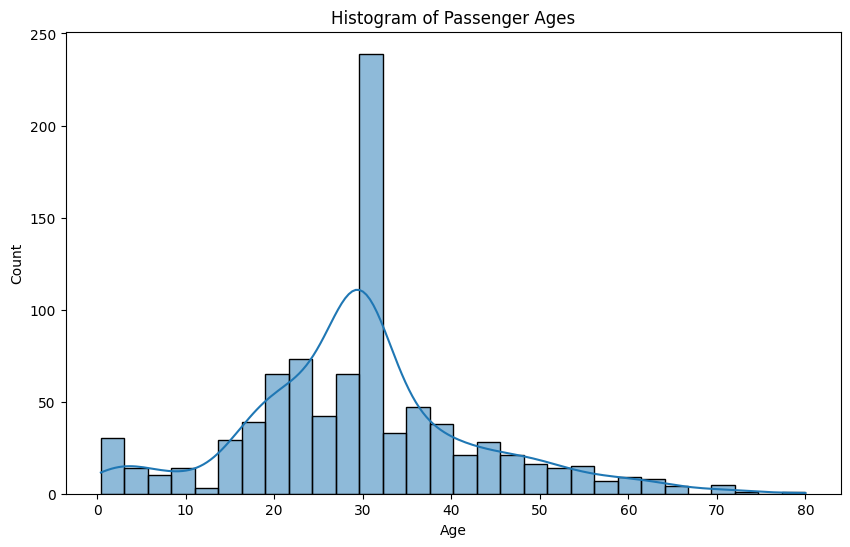

In [13]:
# Task 7: Visualizations
# Create a histogram of passenger ages
plt.figure(figsize=(10, 6))
sns.histplot(titanic_df['Age'], bins=30, kde=True)
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

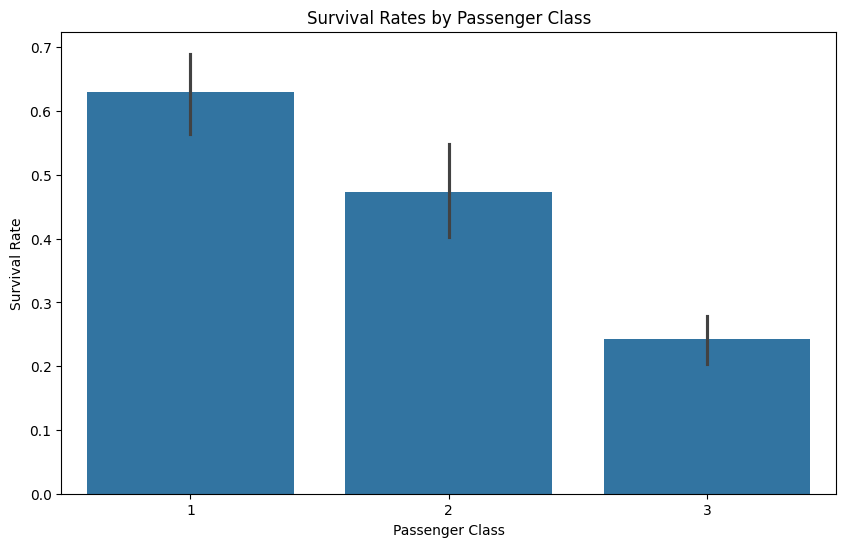

In [14]:
# Create a bar plot of survival rates by passenger class
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', data=titanic_df)
plt.title('Survival Rates by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

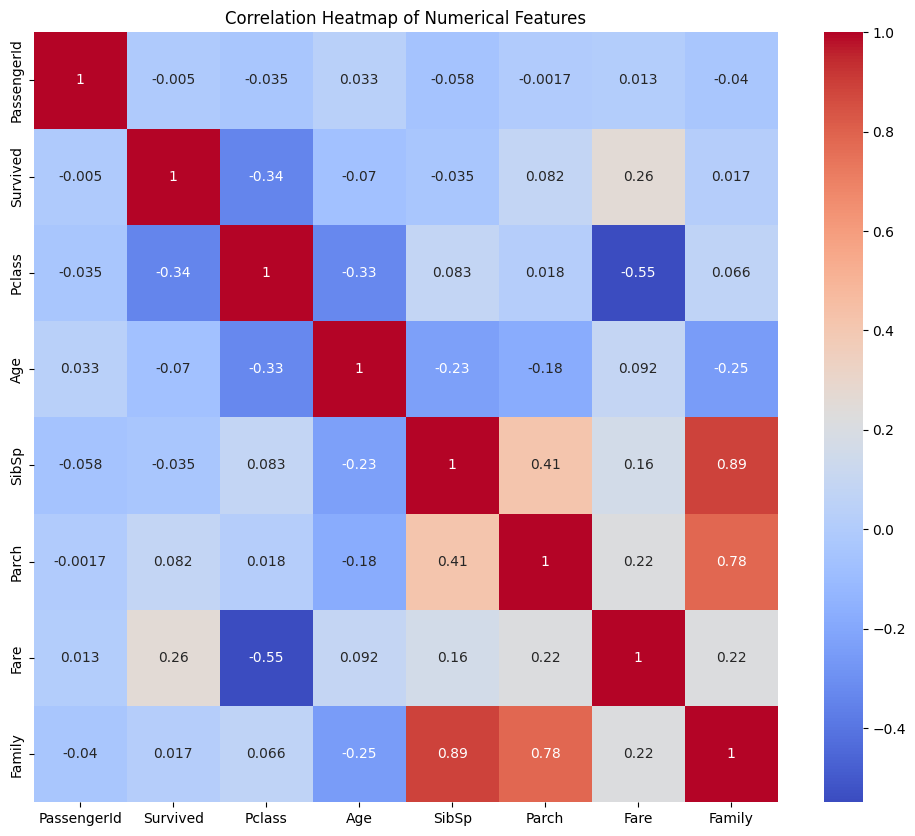

In [16]:
# Create a heatmap of correlation between numerical features
plt.figure(figsize=(12, 10))
numeric_df = titanic_df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

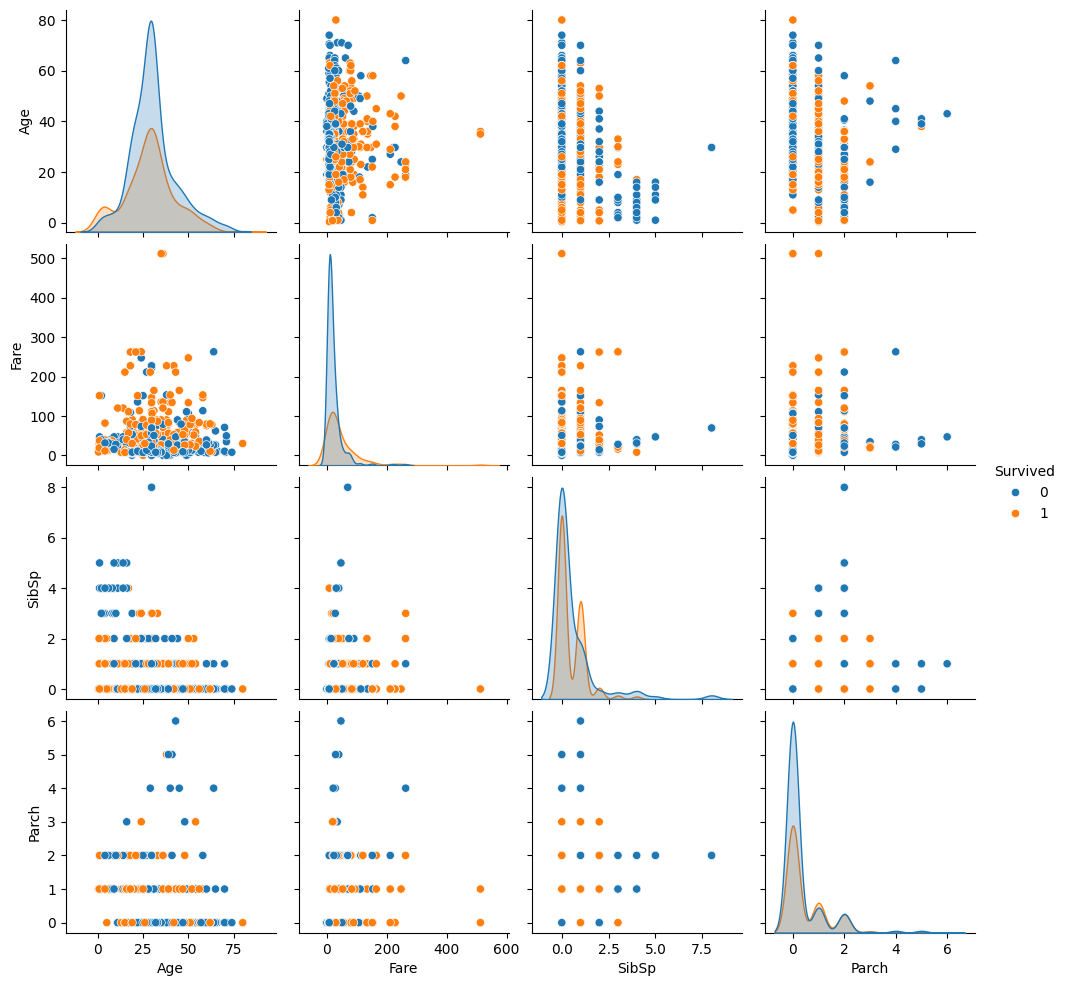

In [17]:
# Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
sns.pairplot(titanic_df, hue='Survived', vars=['Age', 'Fare', 'SibSp', 'Parch'])


In [18]:
# Task 8: Analyze survival rates
# Calculate and display survival rates by sex
survival_by_sex = titanic_df.groupby('Sex')['Survived'].mean().round(3)
print("\nSurvival Rates by Sex:")
print(survival_by_sex)

Survivals_by_class = titanic_df.groupby('Pclass')['Survived'].mean().round(3)
print("\nSurvival Rates by Class:")
print(Survivals_by_class)



Survival Rates by Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Survival Rates by Class:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


## Survival Rate Analysis by Sex and Class

### By Sex
- **Females** had a survival rate of **74.2%**, significantly higher than males.
- **Males** had a survival rate of only **18.9%**, indicating a strong gender disparity in survival outcomes.

### By Passenger Class
- **First Class** passengers had the highest survival rate at **63.0%**.
- **Second Class** passengers followed with **47.3%**.
- **Third Class** passengers had the lowest survival rate at **24.2%**, highlighting the impact of socioeconomic status.

### Insight
Survival likelihood was strongly influenced by both **gender** and **class**, with **female First Class** passengers having the best odds of survival.

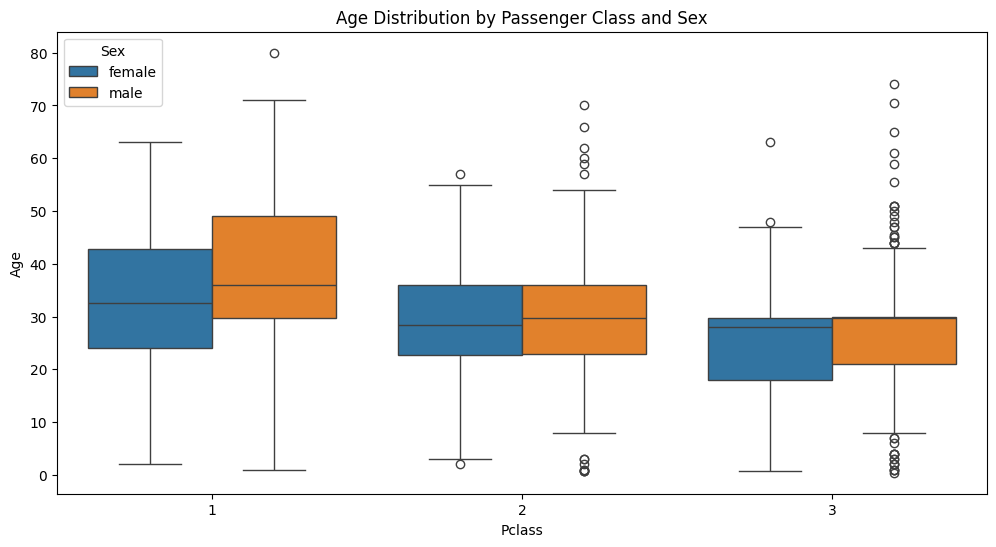

In [19]:
# Task 9: Analyze age distribution
# Create a box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.title('Age Distribution by Passenger Class and Sex')
plt.show()

## Age Distribution by Passenger Class and Sex

This box plot reveals how passenger age varies across different classes and between sexes:

### By Passenger Class
- **Class 1**: Passengers tend to be older overall, especially males. Females show a wider age range and more outliers, suggesting greater diversity in age.
- **Class 2**: Age distributions for males and females are fairly similar, with moderate spread and a few outliers.
- **Class 3**: Passengers are generally younger. Males show a broader age range and more outliers, indicating more variability.

### By Sex
- **Females** in Class 1 are younger on average than their male counterparts.
- **Males** in Class 3 display the widest age spread and the most outliers, possibly reflecting larger family groups or broader socioeconomic diversity.

### Insight
Age distribution varies significantly by both **class** and **sex**, with younger passengers concentrated in **Third Class**, and older passengers more prevalent in **First Class**, especially among males. These patterns may influence survival outcomes and demographic interpretations.

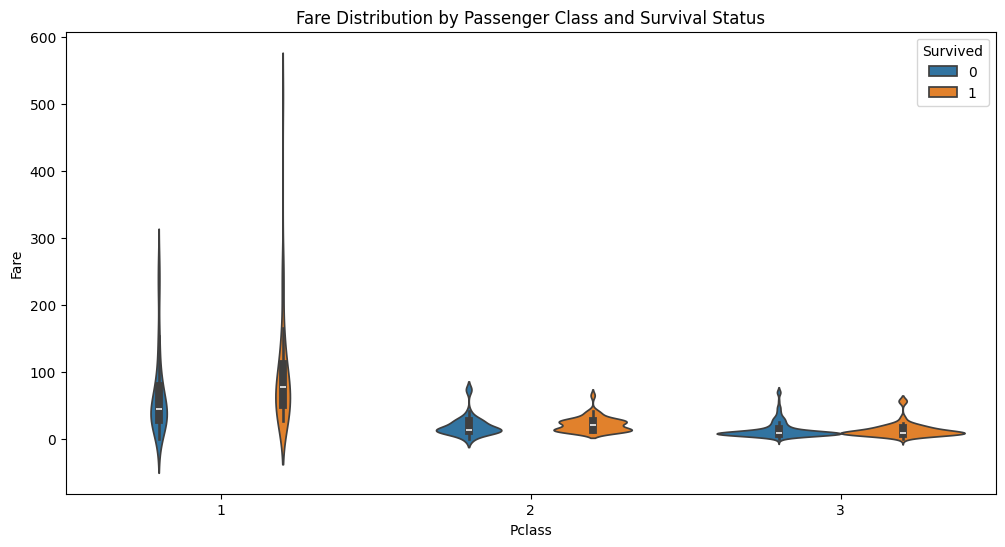

In [20]:
# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))
sns.violinplot(x='Pclass', y='Fare', hue='Survived', data=titanic_df)
plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.show()

## Fare Distribution by Passenger Class and Survival Status

This violin plot illustrates how fare amounts vary across passenger classes and survival outcomes:

### By Passenger Class
- **First Class** shows the widest fare distribution, with many passengers paying high fares (some exceeding £500).
- **Second Class** fares are more moderate, with a narrower spread.
- **Third Class** fares are the lowest and most tightly clustered, reflecting limited economic means.

### By Survival Status
- **Survivors** in First Class generally paid higher fares, suggesting a link between wealth and survival.
- **Non-survivors** in Third Class dominate the lower fare range, with fewer survivors in that group.
- Across all classes, survivors tend to cluster around higher fare values compared to non-survivors.

### Insight
Fare appears to be a strong proxy for **socioeconomic status**, which in turn correlates with **survival odds**. Higher-paying passengers; especially in First Class, had better chances of survival.

In [21]:
print("EDA tasks completed")

EDA tasks completed
